In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from psyduck import Spin
from psyduck.operations import (
    get_spin_operators,
    zeeman_hamiltonian,
    quadrupole_hamiltonian,
)


# Lab Frame (Simplified)

Consider simplified/effective Lab Hamiltonian 

\begin{equation}
 H_{Lab} = E_Z Iz + f_q I_z^2 + f(t)Ix
\end{equation}
where we typically write f(t) as:

\begin{equation}
f(t) = \sum_k a_k(t) cos(2 \pi f_k t + \phi_k(t)) 
\end{equation}

And as an example we consider the specific case of an on-resonance global rotation, where f(t) is the sum of all resonance frequencies so
\begin{equation}
f_k = E_Z + (2 f_q (k - 3)), \text{ for } k\in [0, ..., 7]
\end{equation}
Which we can derive by solving for the eigenstates of $H_{Lab}$ without any drive (f(t)=0)

In [4]:
gamma_sb = 5.5e6
B0 = 1
Ez = B0 * gamma_sb
fq = 20e3

Hlab_static = Ez * Iz + fq *Iz**2

# Zeeman Rotating Frame

We can go into the Zeeman rotating frame (ZRF) using the transformation unitary:
\begin{equation}
S(t) = e^{i 2 \pi E_Z I_z t}
\end{equation}

Which cancels out the Zeeman term on te diagonal 

\begin{equation}
H_{ZRF} = f_q I_z^2 + f(t) S^{\dagger} (t) Ix S(t)
\end{equation}

We can use
\begin{equation}
 f(t) = \sum_k a_k(t) (e^{i 2 \pi f_k t + \phi_k(t)} + e^{-i 2 \pi f_k t + \phi_k(t)})/2
\end{equation}
and some math to find:
\begin{equation}
H_{ZRF} = f_q I_z^2 + \Re\{f'(t)\} I_x + \Im \{ f('t) \} I_y +   \Re\{f'(t)\} e^{2\pi 2 E_z I_z} I_x +   \Im\{f'(t)\} e^{2\pi 2 E_z I_z} I_y
\end{equation}
where
\begin{equation}
f'(t) = \sum_k a_k/2(t) e^{i 2 \pi f'_k t +\phi_k(t)}
\end{equation}
and
\begin{equation}
f'_k = (2 f_q (k - 3)), \text{ for } k\in [0, ..., 7]
\end{equation}



Then doing the rotating wave approximation (RWA) we drop the $2E_z$ oscillating terms assuming they are far detuned with anything we do:

\begin{equation}
H_{ZRF}^{RWA} = f_q I_z^2 + \Re\{f'(t)\} I_x + \Im \{ f'(t) \} I_y
\end{equation}

The RWA is an approximation so we will now ignore some dynamics. However, since 2E_z is typically much larger than our Rabi frequencies we typically ignore this.

Note that here we still use the $I_x/y$ operator meaning we have not yet gotten rid of cross-coupling. Every spin transition sees the same signal f(t), which will not be the case in the GRF. This rotating frame is just as efficient as the generalized rotating frame (maybe even more) if you don't plan on dropping any cross coupling terms.

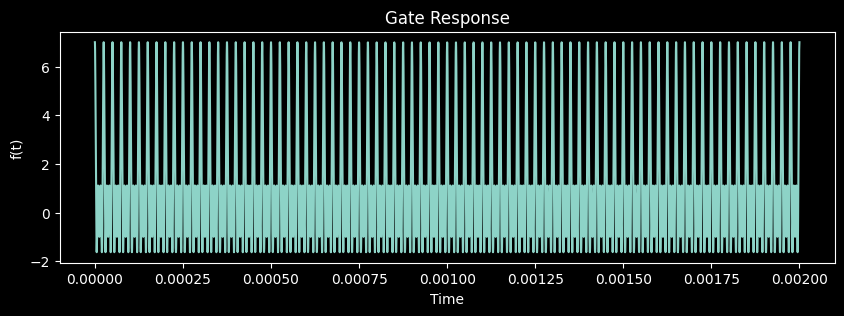

In [12]:
fq = 20e3

H_ZRF_static = fq *Iz**2

f_resonances = -2* np.arange(-3, 4) * fq

amplitude = 500
time_array = np.linspace(0, 1/amplitude,10000)

def f_GR(time, frequencies,):
    f_t = np.zeros(len(time_array), np.complex128)
    for f in frequencies:
        f_t +=  np.exp(2j*np.pi*f*time)
    return f_t

f_t = amplitude*f_GR(time_array, f_resonances)
H_ZRF = [2*np.pi*H_ZRF_static, [Ix, 2*np.pi*np.real(f_t)], [Iy, 2*np.pi*np.imag(f_t)]]


plt.figure(figsize=(10, 3))
plt.plot(time_array, f_GR(time_array, f_resonances))
plt.xlabel('Time')
plt.ylabel('f(t)')
plt.title('Gate Response')
plt.show()


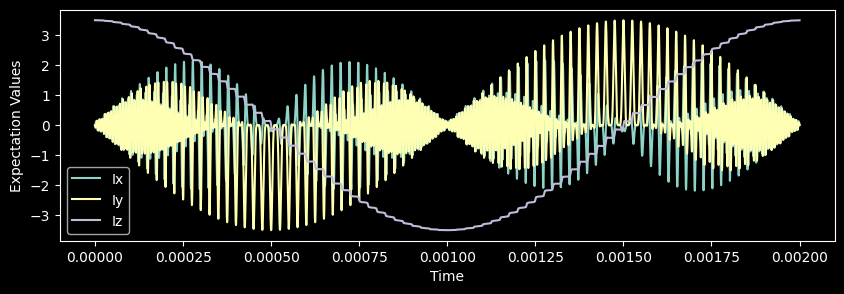

In [6]:
result = qt.sesolve(H_ZRF, qt.basis(8, 0), time_array, e_ops=[Ix, Iy, Iz])


plt.figure(figsize=(10, 3))
plt.plot(time_array, result.expect[0], label='Ix')
plt.plot(time_array, result.expect[1], label='Iy')
plt.plot(time_array, result.expect[2], label='Iz')
plt.xlabel('Time')
plt.ylabel('Expectation Values')
plt.legend()

# Generalized Rotating Frame
The generalized rotating frame (GRF) is the rotating frame where the diagonal of the spin Hamiltonian is zero. This has two advantages. 
- If drive amplitudes are small we can ignore the cross-coupling of different drive frequencies which can make the Hamiltonian time independent.
- In this frame the static Hamiltonian is zero, so the spin is stationary if no drive is applied. This doesn't affect our experimental observable (~I_z), but it is relevant if we care about, for instance, $I_x$ and $I_y$. In the zeeman field these will oscillate a lot but in the generalized rotating frame they are stationary. This is what we usually mean with the $I_x$ operator.

We can make use of the second point without actually dropping the cross-coupling. Which means we simulate the exact same dynamics as in the ZRF section but just with a different frame of reference. Note that we can also do the frame transformation after the simulation is done if we store the states. 

Starting from the ZRF we can go into the GRF through the transformation unitary:
\begin{equation}
S_2(t) = e^{i 2\pi f_q I_z^2 t}
\end{equation}

Unlike the linear $I_z$ operator, now the different spin transitions will be affected differently by this rotating frame. 
From now on, different transitions see different effective frequencies in the GRF, meaning we cannot write our drive 
Hamiltonian as $\Re(f''(t))I_x$ anymore. Instead we will split up the spin operators into transition operators ($T_x^k$, $T_y^k$), that couple neighbouring spin projection states and keep the same coupling strength as the $I_x$ and $I_y$. So $T_x^0$ couples the $7/2 \rightarrow 5/2$ transition in and I_x like way and $T_x^1$ the $5/2 \rightarrow 3/2$ etc. In matrix form: 

\begin{equation}
T_x^2 = \left(\begin{array}{cccccccc}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1.732  & 0 & 0 & 0 & 0 & 0 \\
0 & 1.732 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
\end{array}\right)
\end{equation}

so

\begin{equation}
\sum_k T_x^k = I_x, \sum_k T_y^k = I_y
\end{equation}

We can then write 

\begin{equation}
H_{GRF} = \sum_k \Re\{f'(t)e^{i (2 f_q (k - 3))t} \} T_x^k + \sum_k \Im\{f'(t)e^{i (2 f_q (k - 3))t} \}T_y^k
\end{equation}

If our $f_q >> f_{Rabi}$ we can drop all time-dependent ($e^{i (2 f_q (k - 3))t}$) terms. This is what we call discarding the cross-coupling terms. Since can experimentally operate in a regime where this isn't the case this is an approximation that you don't always want to make.

In [7]:

Ix_transition_ops = []
Iy_transition_ops = []
for i in range(7):
    op = np.zeros((8, 8))
    op[i, i+1] = Ix[i, i+1]
    op[i+1, i] = Ix[i+1, i]
    Ix_transition_ops.append(qt.Qobj(op))
    
    op = np.zeros((8, 8),np.complex128)
    op[i, i+1] = Iy[i, i+1]
    op[i+1, i] = Iy[i+1, i]
    Iy_transition_ops.append(qt.Qobj(op))

# np.sum(Ix_transition_ops)
np.sum(Iy_transition_ops)


C:\Users\z5380600\AppData\Local\Temp\ipykernel_2312\442145522.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  op[i, i+1] = Ix[i, i+1]
C:\Users\z5380600\AppData\Local\Temp\ipykernel_2312\442145522.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  op[i+1, i] = Ix[i+1, i]


Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.+0.j         0.-1.32287566j 0.+0.j         0.+0.j
  0.+0.j         0.+0.j         0.+0.j         0.+0.j        ]
 [0.+1.32287566j 0.+0.j         0.-1.73205081j 0.+0.j
  0.+0.j         0.+0.j         0.+0.j         0.+0.j        ]
 [0.+0.j         0.+1.73205081j 0.+0.j         0.-1.93649167j
  0.+0.j         0.+0.j         0.+0.j         0.+0.j        ]
 [0.+0.j         0.+0.j         0.+1.93649167j 0.+0.j
  0.-2.j         0.+0.j         0.+0.j         0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.j         0.+2.j
  0.+0.j         0.-1.93649167j 0.+0.j         0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.j         0.+0.j
  0.+1.93649167j 0.+0.j         0.-1.73205081j 0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.j         0.+0.j
  0.+0.j         0.+1.73205081j 0.+0.j         0.-1.32287566j]
 [0.+0.j         0.+0.j         0.+0.j         0.+0.j
  0.+0.j         0.+0.

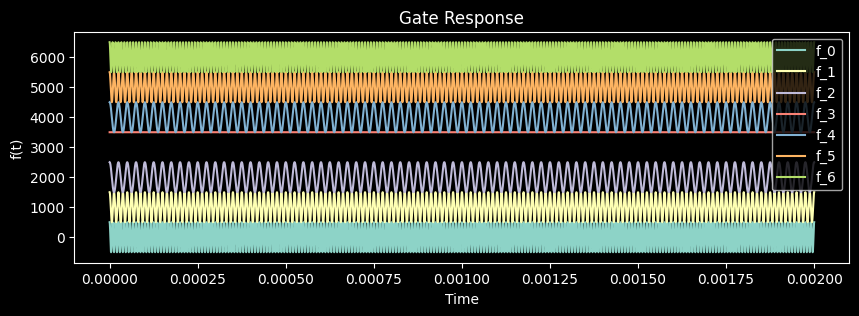

In [8]:




H_GRF_static = 0*qt.identity(8)

f_resonances = -2* np.arange(-3, 4) * fq

amplitude = 500
time_array = np.linspace(0, 1/amplitude, 10000)


def f_GR_GRF(time, frequencies, amplitude):
    f_t = []
    for f in frequencies:
        f_t.append(amplitude * np.exp(2j*np.pi*f*time))
    return f_t

f_t = f_GR_GRF(time_array, f_resonances, amplitude )


add_cross_coupling = False
H_GRF = [2*np.pi*H_GRF_static]
for i in range(7): # for each transititon
    f_k = np.zeros(len(time_array), np.complex128) # singal that we will add to time dependent Hamiltonian for this transition
    for k in range(len(f_t)): # for each frequency component
        if add_cross_coupling or k==i: # if we don't want to add cross coupling we only add the component that is resonant with this transition
            f_k += f_t[k]*np.exp(-1j*2*np.pi*f_resonances[i]*time_array) # add the frequency shifted component 

    H_GRF.extend([[Ix_transition_ops[i], 2*np.pi*np.real(f_k)], [Iy_transition_ops[i], 2*np.pi*np.imag(f_k)] ])


add_cross_coupling = True
H_GRF_with_cross_coupling = [2*np.pi*H_GRF_static]
for i in range(7): # for each transititon
    f_k = np.zeros(len(time_array), np.complex128) # singal that we will add to time dependent Hamiltonian for this transition
    for k in range(len(f_t)): # for each frequency component
        if add_cross_coupling or k==i: # if we don't want to add cross coupling we only add the component that is resonant with this transition
            f_k += f_t[k]*np.exp(-1j*2*np.pi*f_resonances[i]*time_array) # add the frequency shifted component 

    H_GRF_with_cross_coupling.extend([[Ix_transition_ops[i], 2*np.pi*np.real(f_k)], [Iy_transition_ops[i], 2*np.pi*np.imag(f_k)] ])

plt.figure(figsize=(10, 3))
for i in range(len(f_t)):
    plt.plot(time_array, 2*i*amplitude+f_t[i], label=f'f_{i}')
plt.xlabel('Time')
plt.ylabel('f(t)')
plt.title('Gate Response')
plt.legend()
plt.show()


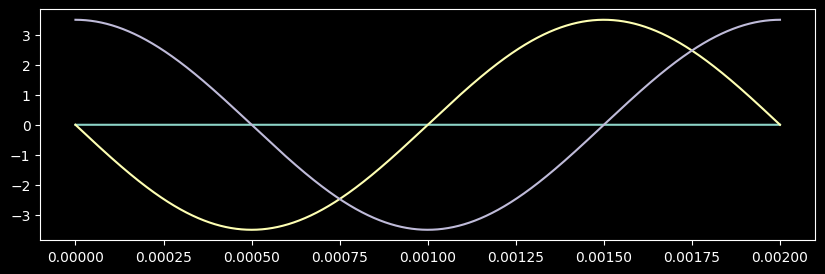

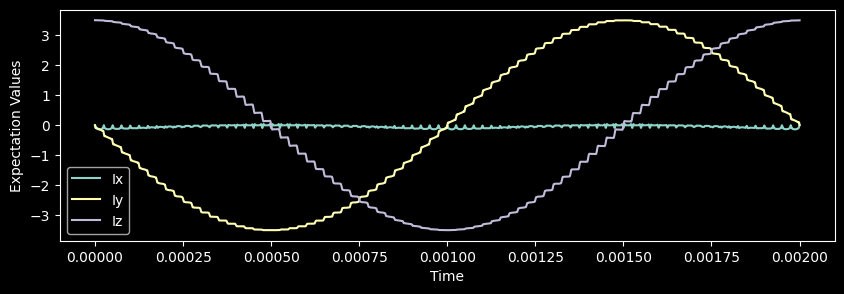

In [9]:
result1 = qt.sesolve(H_GRF, qt.basis(8, 0), time_array, e_ops=[Ix, Iy, Iz])

result2 = qt.sesolve(H_GRF_with_cross_coupling, qt.basis(8, 0), time_array, e_ops=[Ix, Iy, Iz])

plt.figure(figsize=(10, 3))
plt.plot(time_array, result1.expect[0], label='Ix')
plt.plot(time_array, result1.expect[1], label='Iy')
plt.plot(time_array, result1.expect[2], label='Iz')

plt.figure(figsize=(10, 3))

plt.plot(time_array, result2.expect[0], label='Ix')
plt.plot(time_array, result2.expect[1], label='Iy')
plt.plot(time_array, result2.expect[2], label='Iz')
plt.xlabel('Time')
plt.ylabel('Expectation Values')
plt.legend()